<a href="https://colab.research.google.com/github/mwetmore05/A01-data-wrangling/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [To be provided]

**Date:** [To be provided]

#1-1

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Your Phase 1 solution to the problem goes here.
import pandas as pd
airbnb_df = pd.read_csv('/content/airbnb_hw.csv') #all prices in same format
airbnb_df['Price'].head()


print("airbnb_df.shape:") #looking at number of rows and columns
print(airbnb_df.shape, '\n')


print("airbnb_df.dtypes:") # looking at columns type, because an unexpected dtype can flad a variable that needs cleaning
print(airbnb_df.dtypes, '\n')


airbnb_df['Price'] = airbnb_df['Price'].str.replace("$", "", regex=False) #remove $ sign
airbnb_df['Price'] = airbnb_df['Price'].str.replace(",", "", regex=False ) #remove commas sign




airbnb_df.shape:
(30478, 13) 

airbnb_df.dtypes:
Host Id                         int64
Host Since                     object
Name                           object
Neighbourhood                  object
Property Type                  object
Review Scores Rating (bin)    float64
Room Type                      object
Zipcode                       float64
Beds                          float64
Number of Records               int64
Number Of Reviews               int64
Price                          object
Review Scores Rating          float64
dtype: object 



In [ ]:
#I see that the Price variable is an object, I need to tranform it into an int, since the price variable is a whole numbes


airbnb_df['Price'] = pd.to_numeric(airbnb_df['Price'], errors='coerce')
airbnb_df['Price'].dtype


print("Total missing values", airbnb_df['Price'].isna().sum()) #checking total missing values
#making units clear in column name for visual purposes
airbnb_df.rename(columns={'Price' :'Price in US dollars'})
airbnb_df['Price'].head()
airbnb_df['Price'].sort_values() #checking and sorting values ascending order


Total missing values 0


,Price
30087,10
3120,10
19275,10
9793,20
25139,20
...,...
15633,5000
2405,5999
17900,6500
4002,8000


#1-2

In [ ]:
# Your solution to the Minnesota police use-of-force problem goes here.
import pandas as pd
import numpy as np

# Opening the Minnesota police use-of-force CSV file using Pandas
police_df = pd.read_csv('/content/mn_police_use_of_force.csv')

print("police_df.shape:") #looking at the number of rows and columns
print(police_df.shape, '\n')

print("police_df.dtypes:") #looking at the column types because an unexpected dtype can flag a variable that needs cleaning
print(police_df.dtypes, '\n')

print("Unique subject_injury values:")
print(police_df['subject_injury'].unique(), '\n') # examing the possible values of subject_injury before cleaning, allowing me to identify the valid categories and any missing values

print("Counts of subject_injury values:") #including NaN in  counts bc the question specifically asks about missing data
print(police_df['subject_injury'].value_counts(dropna=False), '\n')

police_df['subject_injury_nan'] = police_df['subject_injury'].isnull() # creating another record indicating subject_injury is missing, NaN means that injury status was not recorded or is unknown

print("Total missing subject_injury values:") #finding  total number of missing subject_injury values
print(police_df['subject_injury_nan'].sum(), '\n')

missing_proportion = ( #calculating proportions of missing
    police_df['subject_injury_nan'].sum()
    / len(police_df))

print("Proportion missing:", missing_proportion)
print("Percent missing:", missing_proportion * 100)

# Keeping missing values separate because NaN does not mean that no injury occurred
police_df['subject_injury_clean'] = police_df['subject_injury'].fillna('Missing')

# Cross-tabulation of injury status and force type
injury_force_table = pd.crosstab(
    police_df['force_type'],
    police_df['subject_injury_clean']
)

injury_force_table


police_df.shape:
(12925, 13) 

police_df.dtypes:
response_datetime     object
problem               object
is_911_call           object
primary_offense       object
subject_injury        object
force_type            object
force_type_action     object
race                  object
sex                   object
age                  float64
type_resistance       object
precinct               int64
neighborhood          object
dtype: object 

Unique subject_injury values:
[nan 'No' 'Yes'] 

Counts of subject_injury values:
subject_injury
NaN    9848
Yes    1631
No     1446
Name: count, dtype: int64 

Total missing subject_injury values:
9848 

Proportion missing: 0.7619342359767892
Percent missing: 76.19342359767892


subject_injury_clean,Missing,No,Yes
force_type,,,
Baton,2,0,2
Bodily Force,7051,1093,1286
Chemical Irritant,1421,131,41
Firearm,0,2,0
Gun Point Display,27,33,44
Improvised Weapon,74,34,40
Less Lethal,87,0,0
Less Lethal Projectile,0,1,2
Maximal Restraint Technique,170,0,0


ABout 76.2% of the subject injury values are missing. THe Missig injury data is especially common for bodily foce, chemica irritant, improvised weapon, less lethal, max restraint technique, and taser. The missingness differs by force type so it does not appear random. This tells us something about the missingness of the data and proves it to be important and to always analyze missingness in a dataset before disgarding it.

#2

In [ ]:


# Opening the Excel file
shark = pd.read_excel('/content/GSAF5.xls') #open excel file

shark.head()

shark = shark.drop( #drop columns with NaN data, after seeing almos tno data upon further investigation
    columns=[
        'pdf',
        'href formula',
        'href',
        'Case Number',
        'Case Number.1',
        'original order',
        'Unnamed: 21',
        'Unnamed: 22'
    ]
)



,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,26th August,2026.0,Unprovoked,USA,Hawaii,"Ala Moana Beach Park, Oah'u",Surfing,Unknown Female,F,?,...,Tiger Shark,Keith Cowley: KHON: KITV:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,23rd August,2026.0,Unprovoked,USA,Florida,Boca Grande (island in the keys),Wading on a sandbar,David Daniel,M,43,...,Large shark,Keith Cowley: Todd Smith: NBC 6: ABC News:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19th August,2026.0,Provoked,Reunion Island,Saint-Gilles-les-Baines,Outer Reef Roches Noires,Spearfishiong,Male,M,?,...,Bull shark 2.5m (8.2 ft),Todd Smith: Local Report Zinfos 874:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11th August,2026.0,Provoked,Ireland,Waterford,Ardemore County,Fishing,Sebastian Achim,M,27,...,1.5m (5ft) Blue shark,Keith Cowley: David Bargh: Irish Times BBC Met...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8th August,2026.0,Unprovoked,USA,Maine,Scarborough Beach Park,Operation of Rescue Torpedo,Greg Wilfert,M,71,...,Great White Shark,WGME: CBS News: Keith Cowley,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


count    5581.000000
mean     1992.668518
std        24.311209
min      1940.000000
25%      1970.000000
50%      2000.000000
75%      2013.000000
max      2026.000000
Name: Year, dtype: float64


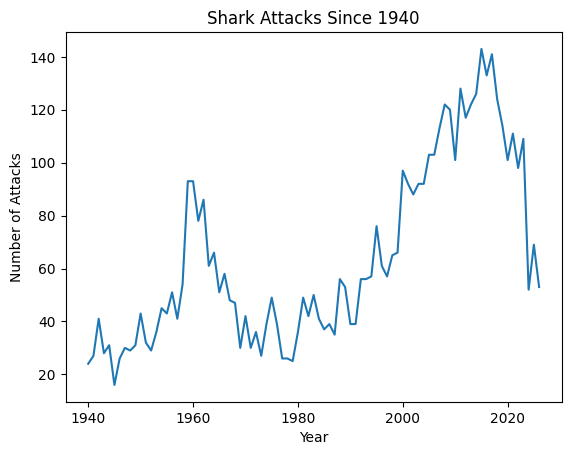

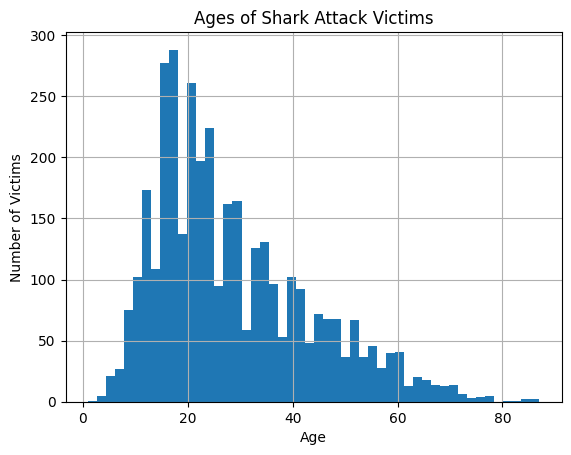

Proportion male: 0.8571707317073171
Proportion unprovoked: 0.7459236695932628


In [ ]:
print(shark['Year'].describe()) #investoigating at the Year variable

shark['Year'] = pd.to_numeric(shark['Year'], errors='coerce') #making 0 as missing for year varaible
shark['Year'] = shark['Year'].replace(0, np.nan)

shark = shark[shark['Year'] >= 1940].copy()  #focus on attacks since 1940

attacks_per_year = shark['Year'].value_counts().sort_index() #looking at the number of attacks per year
attacks_per_year.plot()

plt.xlabel('Year') #making plot to show relationship
plt.ylabel('Number of Attacks')
plt.title('Shark Attacks Since 1940')
plt.show()

shark['Age'] = pd.to_numeric(shark['Age'], errors='coerce') #clean age varaible

shark['Age'].hist(bins=50) #using hisotgram plot to show age varibale
plt.xlabel('Age')
plt.ylabel('Number of Victims')
plt.title('Ages of Shark Attack Victims')
plt.show()

shark['Sex'] = shark['Sex'].str.strip().str.upper() #clean sex varaible

male_proportion = ( #calculating the proportion of recorded victims who are male
    (shark['Sex'] == 'M').sum()
    / shark['Sex'].isin(['M', 'F']).sum()
)
print("Proportion male:", male_proportion)

shark['Type'] = shark['Type'].str.strip().str.lower() #clean type varaible
shark['Type'] = shark['Type'].replace({
    'provoked': 'Provoked',
    'unprovoked': 'Unprovoked'
})

shark.loc[  #changing missing values for type into Unknown, instead of other words
    ~shark['Type'].isin(['Provoked', 'Unprovoked']),
    'Type'
] = 'Unknown'

unprovoked_proportion = ( #calculating proportion of attacks that were unprovoked
    (shark['Type'] == 'Unprovoked').sum()
    / len(shark)
)

print("Proportion unprovoked:", unprovoked_proportion)

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]